Split from audio.ipynb; mostly to prepare for tf.ipynb

# imports

In [1]:
# verify version
import sys
assert sys.version.split('.')[0] == '3'
!which python

/home/gabriel/git/rizhom/env/bin/python


In [2]:
import collections, time

from matplotlib import pyplot as plt
import numpy as np
import numpy
import pandas
import scipy.io.wavfile
import scipy.signal

import pyaudio
import aubio
# import bob.ap

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

import abase, audio, effects as E, features, hotplug, logic as L, settings, signals as S, util

Signal = L.Signal
Effect = E.Effect

hp = hotplug.HotPlug()

Loaded 54 recordings in 0.030ms


# abase

In [75]:
ab = abase.ABase(load_wav=True)
ab.load('logmel')
ab.load('mfccs')
len(ab.df)

loaded 50/54 (92.59%)
loaded 50/54 (92.59%)


54

## transform

Updated 54/54 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/logmel.pickle : 6.60M (0.2s)


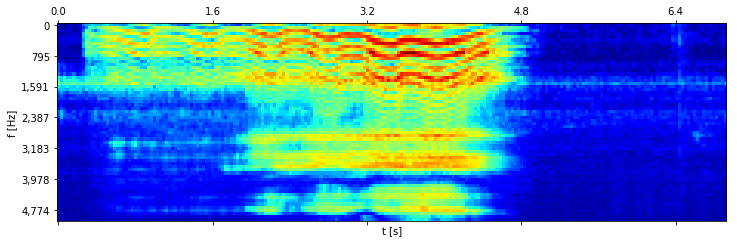

In [76]:
ab.clear('logmel')
ab.transform('logmel', lambda row: features.log_mel_spectrogram(row['wav']))
util.plot_logmel(ab.df.loc[ab.sample(), 'logmel'])

loaded 54/54 (100.00%)
Updated 54/54 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/mfccs.pickle : 1.24M (0.0s)


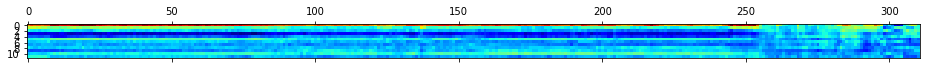

In [77]:
ab.clear('mfccs')
ab.load('logmel')
ab.transform('mfccs', lambda row: features.mfccs(data=None, logmel=row['logmel']))
plt.matshow(ab.df.loc[ab.sample(), 'mfccs'].T, cmap='jet')

nyquist 8000.0
fft_length 0.128
f2hz 7.8125
Updated 54/54 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/fft_2k_100ms.pickle : 8.39M (0.1s)


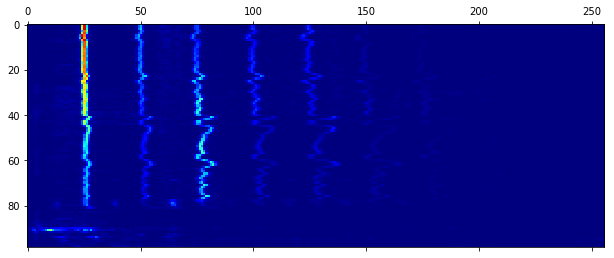

In [78]:
# capped raw fft

from audioset import mel_features

fft_length = window_length = 2**11
hop_length = int(.1 * settings.rate)
f2hz = settings.rate / fft_length
print('nyquist', settings.rate/2)
print('fft_length', fft_length/settings.rate)
print('f2hz', f2hz)

def get_fft(wav, max_hz):
    # x[n] = cos(2*pi*f0*n/fs)
    # => X[n] has peaks at n0, N-n0
    # with f0 = fs * n0 / N
    X = mel_features.stft_magnitude(wav, fft_length=fft_length, 
                                    hop_length=hop_length, window_length=window_length)
    return X[:, :int(max_hz/f2hz)].astype('float')

def fft_2k_100ms(row):
    return get_fft(row['wav'], max_hz=2000)

ab.clear('fft_2k_100ms')
# ab.load('fft_2k_100ms')

ab.transform('fft_2k_100ms', fft_2k_100ms)

# !! turned 90dg for better display
plt.matshow(ab.df.loc[ab.sample(), 'fft_2k_100ms'], cmap='jet', aspect='auto');

In [79]:
# utility for below transformations

def make_fft2func(func, start_secs=0.3, stop_secs=-0.3):
    def fft2func(row):
        fft = row['fft_2k_100ms']
        persec = settings.rate / window_length
        start = int(start_secs * persec)
        stop = int(stop_secs * persec)
        stop = stop if stop > 0 else fft.shape[0] + start
        fft = fft[start: stop]
        return func(fft)
    return fft2func

ignoring frequencies below 15.6Hz...
loaded 54/54 (100.00%)
loaded 50/54 (92.59%)
loaded 50/54 (92.59%)
Updated 0/54 (0.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/loudness.pickle : 0.00M (0.0s)
Updated 0/54 (0.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/loudness_1s.pickle : 0.00M (0.0s)


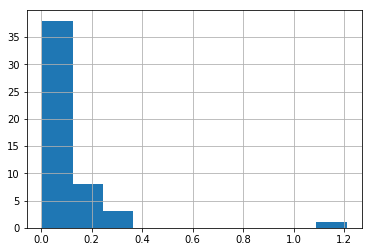

In [80]:
# loudness

import iso226

f0 = 3
freqs = [(f * f2hz) for f in range(fft_length//2 + 1)]
print('ignoring frequencies below %.1fHz...' % freqs[f0 - 1])
contours = iso226.equal_loudness(1, freqs[f0:])
# plt.plot(contours)

def fft2avgloudness(fft):
    return np.array([
        (fft[i, f0:] / contours[:fft.shape[1] - f0]).mean()
        for i in range(fft.shape[0])
    ]).mean()

ab.load('fft_2k_100ms')
ab.load(['loudness', 'loudness_1s'])
# ab.clear(['loudness', 'loudness_1s'])

ab.transform('loudness', make_fft2func(fft2avgloudness))
ab.transform('loudness_1s', make_fft2func(fft2avgloudness, start_secs=1.5, stop_secs=2.5))

ab.df.loudness_1s.hist();

# recordings

In [18]:
import os
import pandas

class DfWrap:
    def __init__(self, df, attr):
        self.df = df
        self.attr = attr
    def __dir__(self):
        return self.df.index.values
    def __getattr__(self, k):
        return getattr(self, 'df').loc[k, getattr(self, 'attr')]

class Recordings:
    def __init__(self, name='recorder2'):
        self.dir = os.path.join(
#             os.path.dirname(__file__),
            '..', 'recordings', name)
        self.load_csv()

    def load_csv(self):
        path = os.path.join(self.dir, 'index.csv')
        mtime = os.path.getmtime(path)
        if not hasattr(self, 'mtime') or self.mtime < mtime:
            self.df = pandas.read_csv(path)
            self.df = self.df.drop_duplicates(subset=('name',), keep='last')
            self.df = self.df.set_index('name')
            self.mtime = mtime
            self.sts = sorted([
                int(name.split('.')[0])
                for name in os.listdir('../recordings/recorder2')
                if name.endswith('.wav')
            ])
            print('(re)loaded index.csv: len={}, {} WAVs'.format(
                len(self.df), len(self.sts)))

    @property
    def ts(self):
        self.load_csv()
        return DfWrap(self.df, 'ts')

    def get_t0_dt(self, ts):
        """Returns start time of recording & distance from start."""
        if isinstance(ts, str):
            if ts not in self.df.index:
                return None, None
            ts = self.df.loc[ts, 'ts']
        # wav name = start time -> choose smaller
        ts0 = self.sts[np.searchsorted(self.sts, ts) - 1]
        return ts0, ts - ts0

    def get_path(self, ts0):
        return os.path.join(self.dir, '{}.wav'.format(ts0))

    def wav(self, ts, before=0, after=10, try_stop=True, dbg=False):
        t0, dt = self.get_t0_dt(ts)
        if dbg:
            print('ts', self.df.loc[ts, 'ts'], 't0', t0, 'dt', dt)
        assert t0 is not None and dt is not None
        if try_stop and isinstance(ts, str):
            stop_t0, stop_dt = self.get_t0_dt(ts + '_stop')
            if stop_t0:
                assert stop_t0 == t0 and stop_dt > dt
                before = 0
                after = stop_dt - dt
        path = self.get_path(t0)
        sr, data = scipy.io.wavfile.read(path)
        secs = len(data) / sr
        if dbg:
            print('secs', secs)
        assert sr == settings.rate
        assert dt < secs
        i1 = int(sr * (dt - before))
        i2 = int(sr * (dt + after))
        return data[i1: i2]

    def play(self, ts, before=0, after=10, try_stop=True):
        audio.playback(self.wav(ts, before=before, after=after, try_stop=try_stop))

r = Recordings()
r.df.tail()

# wav = r.wav('test', dbg=True)

(re)loaded index.csv: len=98, 112 WAVs


,ts
name,
o_r3_s2_stop,1559428502
o_r4_s2,1559428515
o_r4_s2_stop,1559428536
v_r_s2,1559428544
v_r_s2_stop,1559428571


In [19]:
r.play('v_r_s2')

In [213]:
r.play('rf_sound_g2_2', after=3, try_stop=False)

In [234]:
rf_good = []
rf_bad = []
for ts in [ts for ts in r.df.index if ts.startswith('rf_') and not ts.endswith('_stop')]:
    try:
        _ = r.wav(ts)
        rf_good.append(ts)
    except:
        rf_bad.append(ts)
print('good:\n{}\nbad:\n{}'.format(
    '\n'.join(rf_good), '\n'.join(rf_bad)
))

good:
rf_sound1
rf_sound_voice1
rf_sound2
rf_sound_g2
rf_sound_g2_2
rf_sound_g2_m2_1
rf_sound_g1_m2_1
rf_sound_g2_m3s_1
rf_sound_g2_m3s_2
rf_sound_g2_m3s_3
rf_sound_g2_m3m_1
rf_sound_g2_m3m_2
rf_sound_text_noo_g2_m1_1
rf_sound_text_noo_g2_m1_2
rf_sound_text_noo_closed_g2_m1_
rf_sound_var_g2_m1_1
rf_sound_herma_o_g2_m1_
rf_sound_gabe_g2_m1_1
rf_sound_rebi_g2_m1_1
rf_sound_isi_g2_m1_1
rf_music_bass_g2_m1
bad:
rf_nada
rf_nada_box
rf_sound_g2_m2_2
rf_sound_g2_m1_5
rf_sound_text_noo_closedopen_g2_m1_1
rf_sound_text_noo_closedopen_g2_m1_2
rf_sound_voices_g2_m1_1
rf_sound_closed_g2_m1_1
rf_sound_herman_g2_m1_


In [235]:
r.play('rf_sound_g2_m2_1', try_stop=False, after=3)

In [129]:
r.ts.rf_sound_var_g2_m1_1

1559223627

In [135]:
1559223627 - 1559223442

185

In [132]:
r.get_t0_dt('rf_sound_var_g2_m1_1')

(1559223442, 185)

In [133]:
r.get_t0_dt('rf_sound_var_g2_m1_1_stop')

(1559223442, 220)

In [139]:
len(wav) / sr, sr

(112.032, 16000)

In [128]:
r.play('rf_sound_g2_m1_5', try_stop=False)

In [6]:
# Print a list of files to be checked in because they contain named samples.
print('git add {}'.format(' '.join(set([
    r.wav_path(name).split('/')[-1] for name in r.df.index
]))))

git add 1558212022.wav 1558212645.wav 1558210994.wav 1558207087.wav 1558637407.wav 1558212378.wav 1558211537.wav 1558212175.wav


In [74]:
# Convert to ABase files.

import re
def convert_name(name, t):
    # s2
    if t >= 1558211242 and t <= 1558212890:
        m = re.match(r'(\D+)(\d+)', name)
        if not m:
            return None
        what, who = m.groups()
        what = {
            'hoch': 'ohoch',
            'tief': 'otief',
            'i': 'i',
            'var': 'var',
        }[what]
        who = {
            '0': 'g',
            '1': 'a',
            '2': 'm',
            '3': 'p',
            '4': 'k',
        }[who]
        return '{}_{}_s2'.format(what, who)

for name, t in r.df.itertuples():
    newname = convert_name(name, t)
    if not newname:
        continue
    wav = r.wav(t, before=0, after=10)
    path = '../recordings/{}.wav'.format(newname)
    print(path)
    scipy.io.wavfile.write(path, settings.rate, util.float_to_int16(wav))


../recordings/otief_g_s2.wav
../recordings/ohoch_g_s2.wav
../recordings/i_g_s2.wav
../recordings/otief_a_s2.wav
../recordings/ohoch_a_s2.wav
../recordings/i_a_s2.wav
../recordings/var_a_s2.wav
../recordings/otief_m_s2.wav
../recordings/i_m_s2.wav
../recordings/ohoch_m_s2.wav
../recordings/var_m_s2.wav
../recordings/ohoch_p_s2.wav
../recordings/i_p_s2.wav
../recordings/var_p_s2.wav
../recordings/otief_k_s2.wav
../recordings/ohoch_k_s2.wav
../recordings/i_k_s2.wav
../recordings/var_k_s2.wav


## rename prior to commit ddb6c4e

In [217]:
# ugly hack because by accident filenames were generated at the beginning of
# the "frozen" state instead of the end ...

# => NOT SUCCESSFUL

import glob

sts = []
secs = {}
paths = {}
for path in glob.glob('../recordings/recorder2/*.wav'):
    ts = int(path.split('/')[-1].split('.')[0])
    if ts < 1559221895 or ts > 1559224229:
        continue
    sr, wav = scipy.io.wavfile.read(path)
    secs[ts] = int(len(wav)/sr)
    paths[ts] = path
    sts.append(ts)
sts = sorted(sts)

In [232]:
def sft(ts):
    return time.strftime('%Y-%m-%d %H:%M', time.localtime(ts))
def sft2(ts):
    return time.strftime('%H:%M', time.localtime(ts))

for ts in sts:
    print(ts, sft(ts), secs[ts])

for i in range(len(sts) - 1):
    ts = sts[i]
    stops_at = sts[i + 1]
    starts_at = stops_at - secs[ts]
    path = paths[ts]
    cmd = 'git mv {}.wav {}.wav'.format(ts, starts_at)
#     print(cmd)
    print('{}  # {}..{} -> {}..{} (+{}) secs={}'.format(
        cmd,
        sft2(ts), sft2(ts + secs[ts]),
        sft2(starts_at), sft2(stops_at),
        starts_at - ts, secs[ts]))

1559221895 2019-05-30 15:11 451
1559222527 2019-05-30 15:22 221
1559222770 2019-05-30 15:26 260
1559223235 2019-05-30 15:33 151
1559223442 2019-05-30 15:37 112
1559223675 2019-05-30 15:41 35
1559223741 2019-05-30 15:42 363
1559224229 2019-05-30 15:50 673
git mv 1559221895.wav 1559222076.wav
git mv 1559222527.wav 1559222549.wav
git mv 1559222770.wav 1559222975.wav
git mv 1559223235.wav 1559223291.wav
git mv 1559223442.wav 1559223563.wav
git mv 1559223675.wav 1559223706.wav
git mv 1559223741.wav 1559223866.wav


In [231]:
for name, row in r.df.sort_values('ts').iterrows():
    ts = row.ts
    if ts < 1559221895:
        continue
    sft = time.strftime('%Y-%m-%d %H:%M', time.localtime(ts))
    print(ts, sft, name)


1559222190 2019-05-30 15:16 rf_sound1
1559222202 2019-05-30 15:16 rf_sound1_stop
1559222214 2019-05-30 15:16 rf_sound_voice1
1559222215 2019-05-30 15:16 rf_sound_voice1_stop
1559222243 2019-05-30 15:17 rf_sound2
1559222263 2019-05-30 15:17 rf_sound2_stop
1559222290 2019-05-30 15:18 rf_sound_g2
1559222307 2019-05-30 15:18 rf_sound_g2_stop
1559222321 2019-05-30 15:18 rf_sound_g2_2
1559222340 2019-05-30 15:19 rf_sound_g2_2_stop
1559222385 2019-05-30 15:19 7
1559222396 2019-05-30 15:19 rf_sound_g2_m2_1
1559222413 2019-05-30 15:20 rf_sound_g2_m2_1_stop
1559222448 2019-05-30 15:20 rf_sound_g2_m2_2_stop
1559222457 2019-05-30 15:20 rf_sound_g1_m2_1
1559222474 2019-05-30 15:21 rf_sound_g1_m2_1_stop
1559222479 2019-05-30 15:21 rf_sound_g2_m2_2
1559222494 2019-05-30 15:21 rf_sound_g2_m2_27_stop
1559222579 2019-05-30 15:22 rf_sound_g2_m3s_1
1559222607 2019-05-30 15:23 rf_sound_g2_m3s_1_stop
1559222616 2019-05-30 15:23 rf_sound_g2_m3s_2
1559222648 2019-05-30 15:24 rf_sound_g2_m3s_2_stop
1559222675 